# Phase Initialization

This notebook constructs a single-source angular coordinate on an atrial surface using a magnetic FEM eigenproblem. It uses the approximation h = r for the angular scale factor. Mapping this coordinate into cardiac state variables is a subsequent step.

## 1. Atrial geometry

Point 0 is the angular-map source. Point 1 marks a reference direction and defines the global phase offset.


Points shape: (579293, 3)
Elements shape: (1156088, 3)


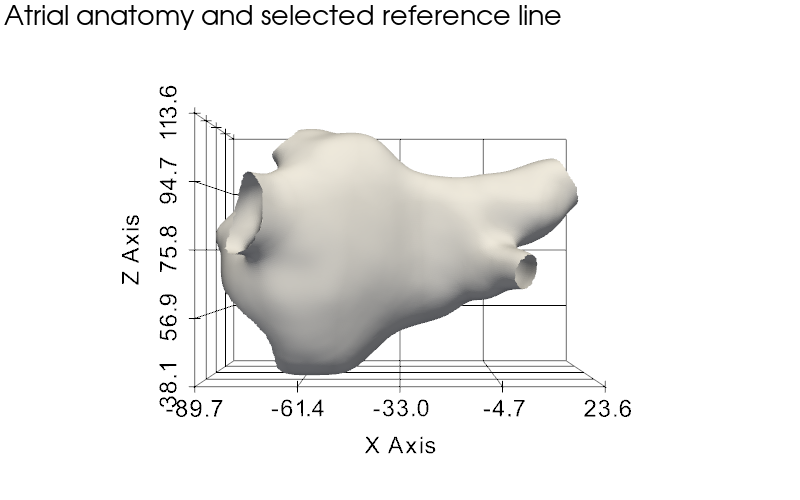

In [22]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave_tools.visualization as fwv
import pyacvd


# Works from the repository root or the Tutorials directory.
path = Path("/Users/arstanbekokenov/Projects/Finitewave/examples/data/atrial_mesh")

points = np.genfromtxt(path / "mesh.pts", skip_header=1) / 1000
elems = np.genfromtxt(path / "mesh.elem", skip_header=1, dtype=int, usecols=(1, 2, 3))

print(f"Points shape: {points.shape}")
print(f"Elements shape: {elems.shape}")

camera_position = "xz"

poly = fwv.PyVistaSurfaceGrid(points, elems)

clustering = pyacvd.Clustering(poly.copy())
clustering.subdivide(2)
clustering.cluster(40000)
remeshed = clustering.create_mesh()

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Atrial anatomy and selected reference line", position="upper_left", font_size=16, color="black")
pl.add_mesh(remeshed, color="white", opacity=1., show_edges=False)
pl.show_grid()
pl.camera_position = camera_position
pl.show()

In [26]:

path = Path("./data")
np.save(path / "atrial_points.npy", remeshed.points.astype(np.float32))
np.save(path / "atrial_elems.npy", remeshed.faces.reshape(-1, 4)[:, 1:].astype(np.int32))

In [23]:
import numpy as np
import pandas as pd

mesh = remeshed.triangulate()

quality = mesh.cell_quality(["area", "min_angle", "max_angle", "aspect_ratio"])

edges = mesh.extract_all_edges().compute_cell_sizes(
    length=True, area=False, volume=False
)

metrics = {
    "edge_length": edges.cell_data["Length"],
    **{name: quality.cell_data[name] for name in
       ["area", "min_angle", "max_angle", "aspect_ratio"]},
}

report = pd.DataFrame({
    name: {
        "min": np.min(values),
        "p05": np.percentile(values, 5),
        "median": np.median(values),
        "p95": np.percentile(values, 95),
        "max": np.max(values),
    }
    for name, values in metrics.items()
}).T

print(f"Vertices: {mesh.n_points}, triangles: {mesh.n_cells}")
print("XYZ extent:", np.ptp(mesh.points, axis=0))
print("Total surface area:", metrics["area"].sum())
display(report)

Vertices: 40000, triangles: 79434
XYZ extent: [113.34959621  60.34622536  75.56659327]
Total surface area: 14728.039515684995


,min,p05,median,p95,max
edge_length,0.464172,0.569420,0.654464,0.767146,1.013377
area,0.116620,0.156423,0.184144,0.218688,0.302753
min_angle,34.275276,45.525864,53.494999,58.365548,59.991736
max_angle,60.011021,61.637585,67.031907,80.773672,101.402678
aspect_ratio,1.000111,1.017283,1.080808,1.256753,1.620854


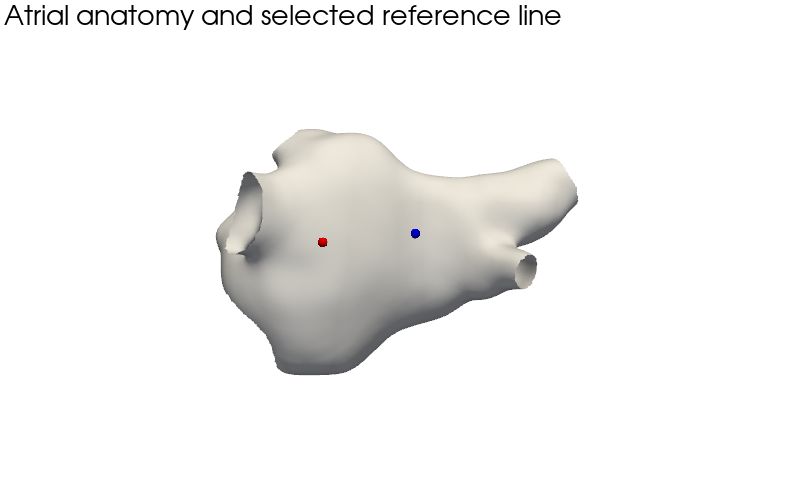

In [1]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave_tools.visualization as fwv


# Works from the repository root or the Tutorials directory.
path = Path(".") if Path("data/atrial_points.npy").exists() else Path("Tutorials")

points = np.load(path / "data/atrial_points.npy")
elems = np.load(path / "data/atrial_elems.npy")

point_0_id = 37508
point_1_id = 18013
camera_position = "xz"

poly = fwv.PyVistaSurfaceGrid(points, elems)

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Atrial anatomy and selected reference line", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, color="white", opacity=1., show_edges=False)
pl.add_points(points[point_0_id], color="red", point_size=10, render_points_as_spheres=True)
pl.add_points(points[point_1_id], color="blue", point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.show()


## 2. Geodesic distances and angular coordinate

The magnetic connection is the circumferential direction around point 0 divided by geodesic distance, using h = r. The second distance field is displayed for comparison; it does not define another phase source.


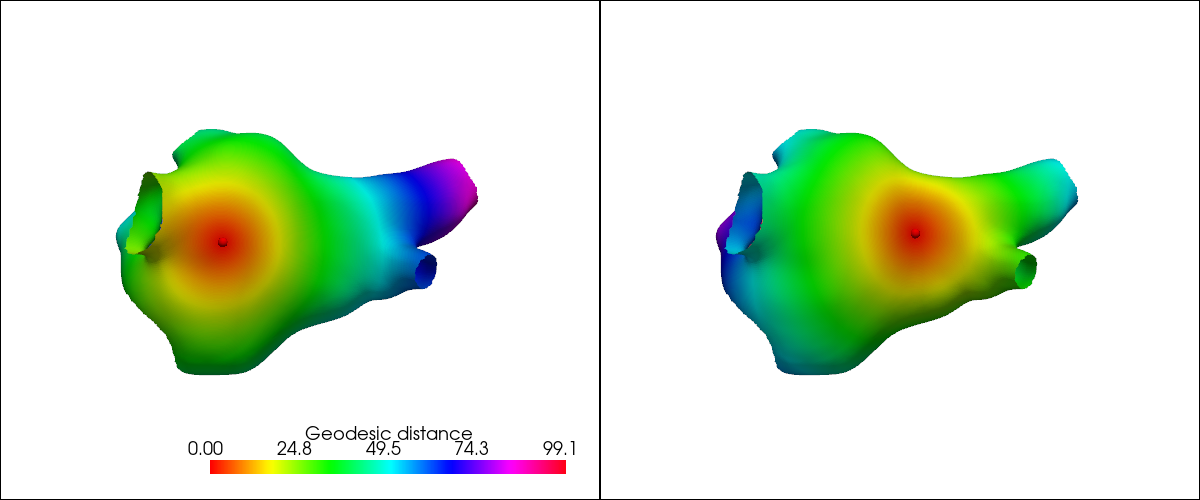

In [ ]:
import numpy as np
import finitewave as fw
from finitewave_tools import linalg as fwlinalg


tissue = fw.CardiacTissueElements(points, elems, elem_type=fw.ElementType.TRIANGLE)

spatial_discretization = fw.FiniteElementDiscretization()
K, M = spatial_discretization.compute_weights(tissue)

areas = spatial_discretization.compute_element_sizes(points, elems)
G = spatial_discretization.build_gradient_operator(points, elems, as_sparse=False)

geo_vec_0 = fwlinalg.geodesic_direction(K, M, G, elems, point_0_id)
geo_vec_1 = fwlinalg.geodesic_direction(K, M, G, elems, point_1_id)

norm_vec = poly.cell_normals
circ_vec_0 = np.cross(geo_vec_0, norm_vec)
circ_vec_1 = np.cross(geo_vec_1, norm_vec)

geo_dist_0 = fwlinalg.geodesic_distance(K, M, G, elems, areas, point_0_id)
geo_dist_1 = fwlinalg.geodesic_distance(K, M, G, elems, areas, point_1_id)

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 2), window_size=(1200, 500))
pl.subplot(0, 0)
pl.add_mesh(poly, scalars=geo_dist_0, cmap="hsv", show_edges=False,
            scalar_bar_args={"title": "Geodesic distance"},
            copy_mesh=True)
pl.add_points(points[point_0_id], color="red", point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.subplot(0, 1)
pl.add_mesh(poly, scalars=geo_dist_1, cmap="hsv", show_edges=False, 
            scalar_bar_args={"title": "Geodesic distance"},
            copy_mesh=True)
pl.add_points(points[point_1_id], color="red", point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.link_views()
pl.show()

In [39]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh


def build_magnetic_laplacian(K, G, elems, areas, circ, geo_dist, epsilon=1e-3):
    r_elem = geo_dist[elems].mean(axis=1)
    phase_grad = circ / np.maximum(r_elem[:, None], epsilon)
    basis_grad = G.transpose(0, 2, 1)

    M_local = (areas[:, None, None] / 12 * (np.ones((3, 3)) + np.eye(3)))

    phase_grad_sq = np.einsum("ed,ed->e", phase_grad, phase_grad)
    V_local = phase_grad_sq[:, None, None] * M_local

    q = np.einsum("eid,ed->ei", basis_grad, phase_grad)

    H_local = (areas[:, None, None] / 3 * (q[:, None, :] - q[:, :, None]))

    N = K.shape[0]

    rows = np.broadcast_to(elems[:, :, None], (len(elems), 3, 3)).ravel()
    cols = np.broadcast_to(elems[:, None, :], (len(elems), 3, 3)).ravel()

    extra = coo_matrix(((V_local + 1j * H_local).ravel(), (rows, cols)), shape=(N, N)).tocsr()

    L = K.astype(complex) + extra
    return L


def solve_magnetic_laplacian(L, M, ref_point_id):
    scale = np.max(np.abs(L.diagonal()) / M.diagonal())
    shift = -1e-6 * scale

    _, eigenvectors = eigsh(
        L,
        M=M,
        k=1,
        sigma=shift,
        which="LM",
    )

    psi = eigenvectors[:, 0]
    psi *= np.exp(-1j * np.angle(psi[ref_point_id]))
    theta = np.angle(psi)
    return theta

L0 = build_magnetic_laplacian(K, G, elems, areas, circ_vec_0, geo_dist_0)
phase_map_0 = solve_magnetic_laplacian(L0, M, point_1_id)
L1 = build_magnetic_laplacian(K, G, elems, areas, -circ_vec_1, geo_dist_1)
phase_map_1 = solve_magnetic_laplacian(L1, M, point_0_id)

phase_map = np.where(np.abs(phase_map_0) > np.abs(phase_map_1), phase_map_0, phase_map_1)


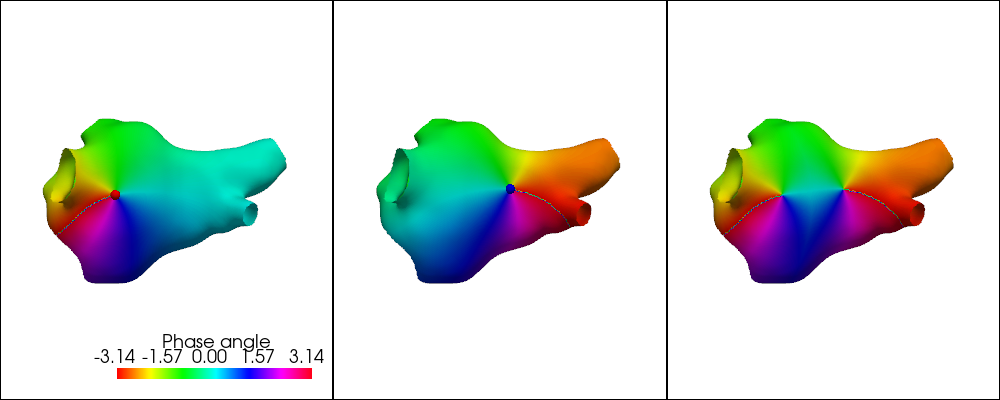

In [4]:
import numpy as np
import finitewave as fw
from finitewave_tools import linalg as fwlinalg


tissue = fw.CardiacTissueElements(points, elems, elem_type=fw.ElementType.TRIANGLE)

spatial_discretization = fw.FiniteElementDiscretization()
K, M = spatial_discretization.compute_weights(tissue)

areas = spatial_discretization.compute_element_sizes(points, elems)
G = spatial_discretization.build_gradient_operator(points, elems, as_sparse=False)

normals_0 = poly.cell_normals
normals_1 = -normals_0

geod_dist_0, geod_phase_0 = fwlinalg.geodesic_coords(K, M, G, elems, areas, normals_0, point_0_id, point_1_id)
geod_dist_1, geod_phase_1 = fwlinalg.geodesic_coords(K, M, G, elems, areas, normals_1, point_1_id, point_0_id)
geod_phase = np.where(np.abs(geod_phase_0) > np.abs(geod_phase_1), geod_phase_0, geod_phase_1)

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 3), window_size=(1000, 400))
pl.subplot(0, 0)
pl.add_mesh(poly, scalars=geod_phase_0, cmap="hsv", clim=(-np.pi, np.pi), show_edges=False,
            scalar_bar_args={"title": "Phase angle"},
            copy_mesh=True)
pl.add_points(points[point_0_id], color="red", point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.subplot(0, 1)
pl.add_mesh(poly, scalars=geod_phase_1, cmap="hsv", clim=(-np.pi, np.pi), show_edges=False,
            scalar_bar_args={"title": "Phase angle"},
            copy_mesh=True)
pl.add_points(points[point_1_id], color="blue", point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.subplot(0, 2)
pl.add_mesh(poly, scalars=geod_phase, cmap="hsv", clim=(-np.pi, np.pi), show_edges=False,
            scalar_bar_args={"title": "Phase angle"},
            copy_mesh=True)
pl.camera_position = camera_position
pl.link_views()
pl.show()

Running Courtemanche on (50, 1) Grid:   0%|          | 0/30000 [00:00<?, ?it/s]

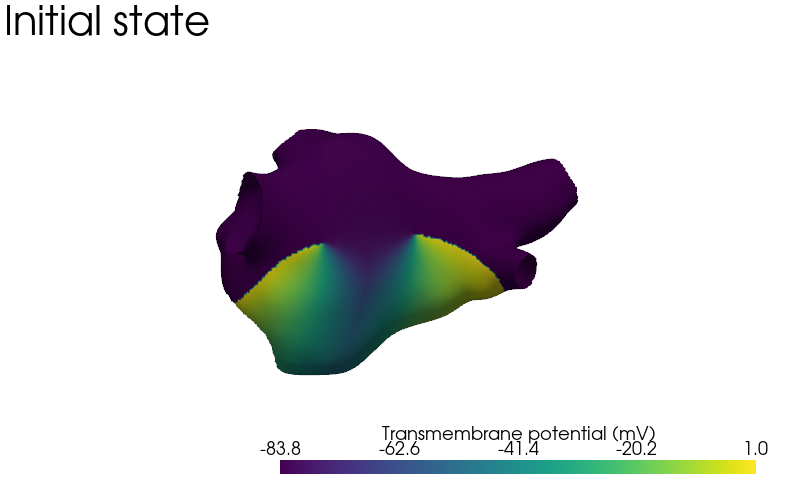

In [42]:

import numpy as np
import pyvista as pv

import finitewave as fw
import numpy as np


remodeled_params =dict(
    gk1 = 2 * 0.09,
    gks = 2 * 0.129,
    gkr = 1.6 * 0.0294,
    gkur = 0.5 * 1.0,
    gcal = 0.45 * 0.1238,
    gto = 0.35 * 0.1652,
    ipcamax = 1.5 * 0.6,
    inacamax = 1.6 * 1600.0
)

stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=100, cycle_length=600, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=100, cycle_length=300, duration=1, curr_value=0.5)

cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)

# create a tissue of size 50x1 to collect the state variables.
n, m = 50, 1
tissue = fw.CardiacTissue([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=100, duration=2,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, m//2)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=300, backend="numba")

simulation.cardiac_model = cardiac_model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

state_vars = {}
n_levels = len(state_tracker.tracking_times[120:])
state_map = n_levels - np.digitize(phase_map, bins=np.linspace(-np.pi, np.pi, n_levels))
for var_name in cardiac_model.state_vars:
    tracked_values = state_tracker.output[var_name][120:]
    var_array = tracked_values[state_map]
    state_vars[var_name] = var_array


pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Initial state", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=state_vars["u"], cmap="viridis", opacity=1,
            scalar_bar_args={"title": "Transmembrane potential (mV)",
                             "color": "black", "n_labels": 5, "fmt": "%.1f"})
pl.camera_position = camera_position
pl.show()


Running Courtemanche on Triangle Elements:   0%|          | 0/50000 [00:00<?, ?it/s]

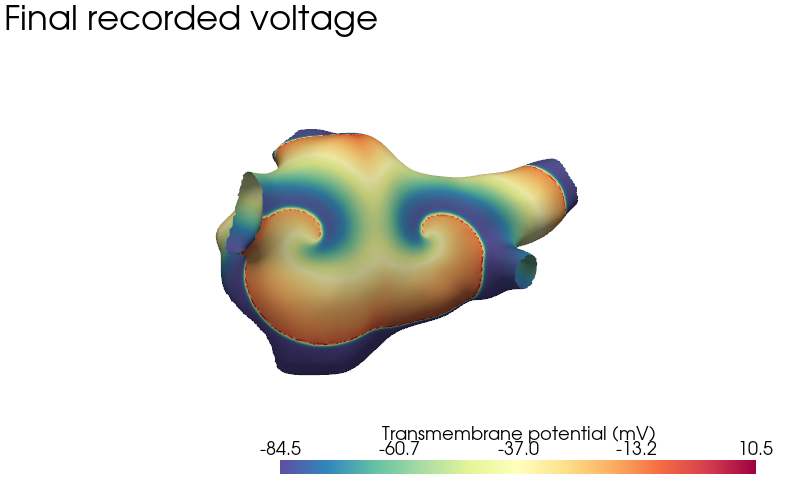

In [43]:
cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)
cardiac_model.set_variables(state_vars)

frame_tracker = fw.FrameTracker(aggregate=True, step=100, start_time=300)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.02, t_max=1000, backend="jax")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                             elem_type=fw.ElementType.TRIANGLE)
simulation.cardiac_model = cardiac_model
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6, maxiter=100, lumping_factor=1.0, reaction_lumping=True)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(frame_tracker)

# run the model:
simulation.run()

u = cardiac_model.u

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Final recorded voltage", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=u, cmap="Spectral_r", opacity=1,
            scalar_bar_args={"title": "Transmembrane potential (mV)",
                             "color": "black", "n_labels": 5, "fmt": "%.1f"})
pl.camera_position = camera_position
pl.show()

In [46]:
from pathlib import Path
import numpy as np
import finitewave_tools.visualization as fwv
import finitewave_tools.animation as fwa

# get the resulting potential at the element centers:
sample_times = frame_tracker.tracking_times
frames = frame_tracker.frames

animation_name = "phase_initialization"

scalar_name = "Membrane potential (mV)"

animation_grid = fwv.PyVistaSurfaceGrid(points, elems)

renderer = fwa.Frame3DRenderer()
renderer.set_frames(frames=frames)
renderer.configure_grid(animation_grid, window_size=(1920, 1080))

output_dir = Path("./output")
output_dir.mkdir(parents=True, exist_ok=True)

animation = fwa.AnimationBuilder()
animation.frame_renderer = renderer
animation.write(
    path=output_dir,
    animation_name=animation_name,
    fps=40,
    prog_bar=True,
    scalar_name=scalar_name,
    cmap="plasma",
    nan_color="white",
    clim=(-90.0, 10.0),
    camera_position=camera_position,
)

video_path = output_dir / f"{animation_name}.mp4"


Building animation:   0%|          | 0/351 [00:00<?, ?it/s]

In [47]:
from IPython.display import Video, display

display(Video(str(video_path), embed=True, width=800))